In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

pd.set_option("display.max_columns",None)

In [42]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# Remove duplicates
df = df.drop_duplicates()

# Mixed date format
df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Clean Amount
df["Amount"] = (
    df["Amount"]
      .astype(str)
      .str.replace("₹","",regex=False)
      .str.replace(",","",regex=False)
)

df["Amount"] = pd.to_numeric(df["Amount"],errors="coerce")

# Standardize Type
df["Type"] = (
    df["Type"]
      .astype(str)
      .str.upper()
)

df["Type"] = df["Type"].replace({
    "DR":"Debit",
    "CR":"Credit"
})

# New Columns
df["Month"] = df["Date"].dt.month_name()
df["Hour"] = df["Time"].str[:2].astype(int)

print(df.head())

Saving Data set for DADS June.csv to Data set for DADS June (3).csv
        Date   Time                       Description    Type   Amount   Balance  Mode        Ref    Month  Hour
0 2024-01-01  03:11                AMAZON SELLER SVCS   DEBIT   2462.0  678275.0   UPI  TXN190872  January     3
1 2024-01-01  05:44                         BHIM-BMTC   Debit     50.0  681007.0   UPI  TXN143064  January     5
2 2024-01-01  09:35  NEFT-TECHCRUSH LABS-SALARY MAY24  Credit  84728.0  484728.0  NEFT  TXN246316  January     9
3 2024-01-01  14:07              UPI-AMAN-8934@OKAXIS   DEBIT   1828.0 -748745.0   UPI  TXN569226  January    14
4 2024-01-01  14:23                      BHIM-BLINKIT   DEBIT    270.0  680737.0   UPI  TXN968962  January    14


In [43]:
def vendor(desc):

    desc = str(desc).upper()

    if "SWIGGY" in desc:
        return "Swiggy"

    elif "ZOMATO" in desc:
        return "Zomato"

    elif "BLINKIT" in desc:
        return "Blinkit"

    elif "ZEPTO" in desc:
        return "Zepto"

    elif "AMAZON" in desc:
        return "Amazon"

    elif "UBER" in desc:
        return "Uber"

    elif "OLA" in desc:
        return "Ola"

    elif "NETFLIX" in desc:
        return "Netflix"

    elif "SPOTIFY" in desc:
        return "Spotify"

    elif "BMTC" in desc:
        return "BMTC"

    else:
        return "Others"

df["Vendor"] = df["Description"].apply(vendor)

df[["Description","Vendor"]].head()

,Description,Vendor
0,AMAZON SELLER SVCS,Amazon
1,BHIM-BMTC,BMTC
2,NEFT-TECHCRUSH LABS-SALARY MAY24,Others
3,UPI-AMAN-8934@OKAXIS,Others
4,BHIM-BLINKIT,Blinkit


In [44]:
def category(vendor):

    if vendor in ["Swiggy","Zomato"]:
        return "Food Delivery"

    elif vendor in ["Blinkit","Zepto"]:
        return "Quick Commerce"

    elif vendor=="Amazon":
        return "E-Commerce"

    elif vendor in ["Uber","Ola","BMTC"]:
        return "Transport"

    elif vendor in ["Netflix","Spotify"]:
        return "Subscription"

    else:
        return "Others"

df["Category"] = df["Vendor"].apply(category)

print(df[["Vendor","Category"]].head(20))

     Vendor        Category
0    Amazon      E-Commerce
1      BMTC       Transport
2    Others          Others
3    Others          Others
4   Blinkit  Quick Commerce
5     Zepto  Quick Commerce
6      Uber       Transport
7   Blinkit  Quick Commerce
8    Swiggy   Food Delivery
9    Others          Others
10      Ola       Transport
11   Others          Others
12      Ola       Transport
13   Swiggy   Food Delivery
14   Others          Others
15   Others          Others
16   Others          Others
17     BMTC       Transport
18   Others          Others
19   Others          Others


In [45]:
# Debit and Credit Data

debit = df[df["Type"] == "Debit"].copy()
credit = df[df["Type"] == "Credit"].copy()

print("="*60)
print("SPENDING OVERVIEW")
print("="*60)

print("Total Transactions :",len(df))
print("Debit Transactions :",len(debit))
print("Credit Transactions :",len(credit))

print()

print("Total Debit : ₹",round(debit["Amount"].sum(),2))
print("Total Credit : ₹",round(credit["Amount"].sum(),2))

net = credit["Amount"].sum()-debit["Amount"].sum()

print("Net Savings : ₹",round(net,2))

rate=(net/credit["Amount"].sum())*100

print("Savings Rate :",round(rate,2),"%")

SPENDING OVERVIEW
Total Transactions : 1310
Debit Transactions : 662
Credit Transactions : 6

Total Debit : ₹ 631479.0
Total Credit : ₹ 425073.0
Net Savings : ₹ -206406.0
Savings Rate : -48.56 %


In [46]:
print("="*60)
print("TOP CATEGORIES")
print("="*60)

cat = debit.groupby("Category")["Amount"].sum().sort_values(ascending=False)

print(cat)

print()

print("="*60)
print("TOP VENDORS")
print("="*60)

vendor = debit.groupby("Vendor")["Amount"].sum().sort_values(ascending=False)

print(vendor.head(10))

TOP CATEGORIES
Category
Others            417094.0
E-Commerce        126284.0
Food Delivery      55385.0
Transport          16146.0
Quick Commerce     15522.0
Subscription        1048.0
Name: Amount, dtype: float64

TOP VENDORS
Vendor
Others     417094.0
Amazon     126284.0
Swiggy      31858.0
Zomato      23527.0
Zepto        9776.0
Uber         9165.0
Ola          6469.0
Blinkit      5746.0
Netflix       691.0
BMTC          512.0
Name: Amount, dtype: float64


MONTHLY SPENDING
Date
January      100950.0
February     104576.0
March        127360.0
April        110029.0
May           91723.0
June          96841.0
July              0.0
August            0.0
September         0.0
October           0.0
November          0.0
December          0.0
Name: Amount, dtype: float64


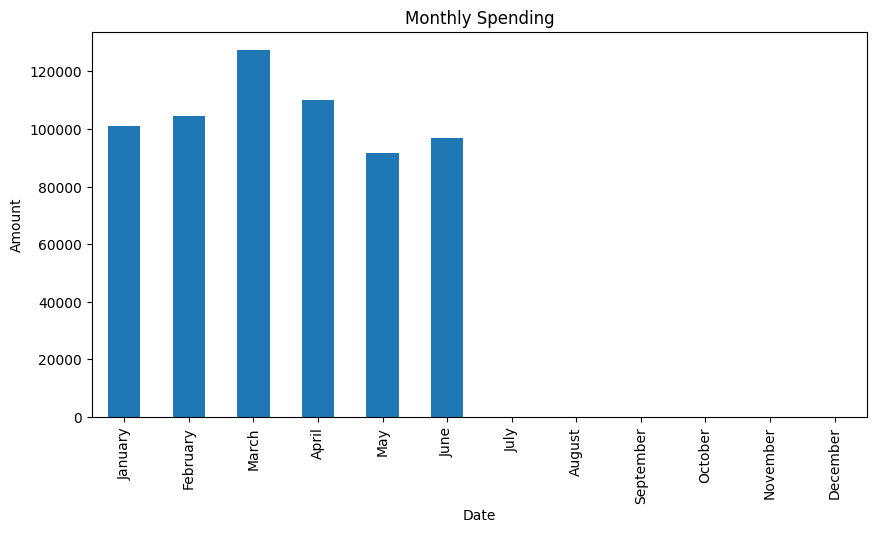

In [47]:
monthly = (
    debit.groupby(df["Date"].dt.month_name())["Amount"]
    .sum()
    .reindex(calendar.month_name[1:],fill_value=0)
)

print("="*60)
print("MONTHLY SPENDING")
print("="*60)

print(monthly)

monthly.plot(
    kind="bar",
    figsize=(10,5),
    title="Monthly Spending"
)

plt.ylabel("Amount")
plt.show()

In [48]:
print("="*60)
print("ANOMALY DETECTION")
print("="*60)

debit["Mean"] = debit.groupby("Category")["Amount"].transform("mean")
debit["Std"] = debit.groupby("Category")["Amount"].transform("std")

debit["ZScore"] = (
    (debit["Amount"] - debit["Mean"]) /
    debit["Std"]
)

debit["ZScore"] = debit["ZScore"].fillna(0)

anomaly = debit[debit["ZScore"] > 2]

print("Total Anomalies :", len(anomaly))

print(anomaly[
    ["Date","Vendor","Category","Amount","ZScore"]
].head(10))

ANOMALY DETECTION
Total Anomalies : 18
          Date   Vendor        Category   Amount    ZScore
70  2024-01-09   Others          Others  10745.0  2.856221
169 2024-01-24   Others          Others  16260.0  4.602284
272 2024-02-08   Others          Others  15000.0  4.203364
414 2024-02-26   Others          Others   8383.0  2.108405
456 2024-03-03   Others          Others  18000.0  5.153172
486 2024-03-07   Others          Others  15000.0  4.203364
617 2024-03-26   Others          Others  15000.0  4.203364
698 2024-04-05  Blinkit  Quick Commerce    881.0  2.338197
699 2024-04-05   Others          Others  14305.0  3.983326
713 2024-04-08   Others          Others  15000.0  4.203364


TIME OF DAY ANALYSIS
Hour
0     12169.0
1     10082.0
2     11491.0
3     11071.0
4     10232.0
5     12403.0
6     26115.0
7      9343.0
8      9181.0
9     41456.0
10    63011.0
11    30668.0
12    27967.0
13    43869.0
14    62571.0
15    10391.0
16    31482.0
17    14289.0
18    43357.0
19    18849.0
20    83679.0
21    23713.0
22    13367.0
23    10723.0
Name: Amount, dtype: float64


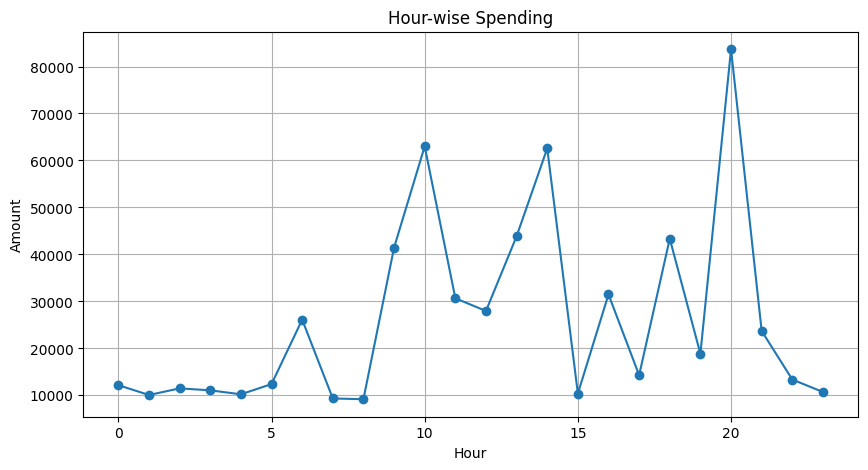


Peak Spending Hour : 20 :00


In [49]:
print("="*60)
print("TIME OF DAY ANALYSIS")
print("="*60)

hourly = debit.groupby("Hour")["Amount"].sum()

print(hourly)

plt.figure(figsize=(10,5))
hourly.plot(marker="o")

plt.title("Hour-wise Spending")
plt.xlabel("Hour")
plt.ylabel("Amount")
plt.grid(True)

plt.show()

peak_hour = hourly.idxmax()

print("\nPeak Spending Hour :",peak_hour,":00")

In [50]:
"""print("="*60)
print("ANOMALY DETECTION")
print("="*60)

mean = debit["Amount"].mean()
std = debit["Amount"].std()

debit["ZScore"] = (debit["Amount"]-mean)/std

anomaly = debit[abs(debit["ZScore"])>2]

print("Total Anomalies :",len(anomaly))

print()

print(anomaly[
    ["Date",
     "Vendor",
     "Category",
     "Amount",
     "ZScore"]
].head(10))

ANOMALY DETECTION
Total Anomalies : 20

          Date  Vendor    Category   Amount    ZScore
70  2024-01-09  Others      Others  10745.0  3.440892
99  2024-01-14  Others      Others   7707.0  2.337560
169 2024-01-24  Others      Others  16260.0  5.443815
272 2024-02-08  Others      Others  15000.0  4.986211
336 2024-02-17  Amazon  E-Commerce  13674.0  4.504638
414 2024-02-26  Others      Others   8383.0  2.583068
456 2024-03-03  Others      Others  18000.0  6.075743
464 2024-03-04  Others      Others   7441.0  2.240955
486 2024-03-07  Others      Others  15000.0  4.986211
487 2024-03-07  Others      Others   7366.0  2.213717


In [53]:
print("="*75)
print("                 SPENDDNA REPORT")
print("="*75)

print("\nCUSTOMER NAME : Rahul Sharma")
print("PROJECT       : SpendDNA - Personal Finance Analysis")

print("\n" + "="*75)
print("SUMMARY")
print("="*75)

print(f"Total Transactions : {len(df)}")
print(f"Debit Transactions : {len(debit)}")
print(f"Credit Transactions: {len(credit)}")

print(f"\nTotal Debit  : ₹{debit['Amount'].sum():,.2f}")
print(f"Total Credit : ₹{credit['Amount'].sum():,.2f}")

net = credit["Amount"].sum() - debit["Amount"].sum()
print(f"Net Savings  : ₹{net:,.2f}")

savings = (net / credit["Amount"].sum()) * 100
print(f"Savings Rate : {savings:.2f}%")

print("\n" + "="*75)
print("TOP 5 SPENDING CATEGORIES")
print("="*75)

category_summary = (
    debit.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_percent = (category_summary / category_summary.sum()) * 100

for cat, amt in category_summary.head(5).items():
    print(f"{cat:<20} ₹{amt:>12,.2f}   ({category_percent[cat]:5.2f}%)")

print("\n" + "="*75)
print("TOP 5 VENDORS")
print("="*75)

vendor_summary = (
    debit.groupby("Vendor")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

for ven, amt in vendor_summary.head(5).items():
    print(f"{ven:<20} ₹{amt:>12,.2f}")

print("\n" + "="*75)
print("MONTHLY SPENDING")
print("="*75)

monthly = (
    debit.groupby(debit["Date"].dt.month_name())["Amount"]
    .sum()
    .reindex(calendar.month_name[1:], fill_value=0)
)

for month, amt in monthly.items():
    if amt > 0:
        print(f"{month:<12} ₹{amt:>12,.2f}")

print("\nHighest Spending Month :", monthly.idxmax())
print("Lowest Spending Month  :", monthly[monthly > 0].idxmin())

print("\n" + "="*75)
print("TIME ANALYSIS")
print("="*75)

hourly = debit.groupby("Hour")["Amount"].sum()

print("Peak Spending Hour :", f"{hourly.idxmax()}:00")

print("\nTop 5 Busy Hours")

for hr, amt in hourly.sort_values(ascending=False).head(5).items():
    print(f"{int(hr):02d}:00   ₹{amt:,.2f}")

print("\n" + "="*75)
print("ANOMALY DETECTION")
print("="*75)

print("Total Anomalies :", len(anomaly))

print("\nTop 5 Anomalies")

print(
    anomaly[
        ["Date", "Vendor", "Category", "Amount"]
    ].head().to_string(index=False)
)

print("\n" + "="*75)
print("SPENDING ARCHETYPE")
print("="*75)

food = category_percent.get("Food Delivery", 0)

shop = category_percent.get("E-Commerce", 0)

quick = category_percent.get("Quick Commerce", 0)

if food > 20:
    print("Food Lover")

if quick > 15:
    print("Quick Commerce User")

if shop > 15:
    print(" Online Shopper")

if savings > 30:
    print(" Disciplined Saver")
else:
    print(" Active Spender")

print("\n" + "="*75)
print("END OF REPORT")
print("="*75)

                 SPENDDNA REPORT

CUSTOMER NAME : Rahul Sharma
PROJECT       : SpendDNA - Personal Finance Analysis

SUMMARY
Total Transactions : 1310
Debit Transactions : 662
Credit Transactions: 6

Total Debit  : ₹631,479.00
Total Credit : ₹425,073.00
Net Savings  : ₹-206,406.00
Savings Rate : -48.56%

TOP 5 SPENDING CATEGORIES
Others               ₹  417,094.00   (66.05%)
E-Commerce           ₹  126,284.00   (20.00%)
Food Delivery        ₹   55,385.00   ( 8.77%)
Transport            ₹   16,146.00   ( 2.56%)
Quick Commerce       ₹   15,522.00   ( 2.46%)

TOP 5 VENDORS
Others               ₹  417,094.00
Amazon               ₹  126,284.00
Swiggy               ₹   31,858.00
Zomato               ₹   23,527.00
Zepto                ₹    9,776.00

MONTHLY SPENDING
January      ₹  100,950.00
February     ₹  104,576.00
March        ₹  127,360.00
April        ₹  110,029.00
May          ₹   91,723.00
June         ₹   96,841.00

Highest Spending Month : March
Lowest Spending Month  : May

TIME A